In [1]:
import geopandas as gpd
import glob
import numpy as np
import pandas as pd

In [2]:
basin_shp_fname = glob.glob('past_dwr_extractions/ensemble_et_202312_ave_BASIN/*.shp')[0]
basin_gdf = gpd.read_file(basin_shp_fname)
basin_gdf['area_sq_meters'] = basin_gdf.area
basin_gdf['area_acres']=basin_gdf.area_sq_meters/4046.86
basin_slim = basin_gdf[['Basin_Numb', 'Basin_Subb', 'Basin_Name','Basin_Su_1','area_acres','geometry']]

In [80]:
csv_fnames = glob.glob('csv_gw_basin_all_lands/*all_m*.csv')
# csv_fnames = glob.glob('csv_gw_basin_ag_lands/*all_m*.csv')

In [81]:
all_data_df = pd.read_csv(csv_fnames[0])

In [82]:
# assign date-time to date
all_data_df["DATE"] = pd.to_datetime(all_data_df["DATE"])
# Reformat to YYYY_MM
all_data_df["date_combo"] = all_data_df["DATE"].dt.strftime("%y%m")

# compute maximum pixels by basin
max_pixels = all_data_df[['PIXEL_COUNT','Basin_Subb']].groupby('Basin_Subb').max()
# convert to series to divide into dataframe along rows
max_pixels_series = max_pixels['PIXEL_COUNT']


In [83]:
# all_data_df["MODEL"].str.slice(0, 3).unique()
# all_data_df["date_combo"]

In [84]:
vars = ['MEAN','MEDIAN','STDDEV','PCT75','PCT25','PER_COV']
abreviations={'MEAN':'avg','MEDIAN':'med','STDDEV':'std','PCT75':'p75','PCT25':'p25','PER_COV':'cov'}

i=0

for v in vars:
    print(v)
    if v =='PER_COV':
        vv = abreviations[v]
        all_data_df[vv] = (all_data_df["MODEL"].str.slice(0, 3)+f"{vv}" +all_data_df["date_combo"].astype(str))
        # Pivot so basin becomes rows and concatenated values become columns
        result_i_all = all_data_df.pivot_table(
                                            index="Basin_Subb",
                                            columns=vv,
                                            values="PIXEL_COUNT",
                                            aggfunc="first"
                                            )
        result_i = result_i_all.div(max_pixels_series,axis=0)
        
    else: 
        vv = abreviations[v]
        all_data_df[vv] = (all_data_df["MODEL"].str.slice(0, 3)+f"{vv}" +all_data_df["date_combo"].astype(str))

        
        # Pivot so basin becomes rows and concatenated values become columns
        result_i = all_data_df.pivot_table(
                                            index="Basin_Subb",
                                            columns=vv,
                                            values=f"ET_{v}",
                                            aggfunc="first"
                                            )
    if i==0:
        merged = pd.merge(basin_slim, 
                          result_i, 
                          left_on="Basin_Subb",
                          right_index=True,
                          how="left")
    else:
        merged = pd.merge(merged, 
                          result_i, 
                          left_on="Basin_Subb",
                          right_index=True,
                          how="left")        
    
    i+=1
    


MEAN
MEDIAN
STDDEV
PCT75
PCT25
PER_COV


In [85]:
modshort = all_data_df["MODEL"].str.slice(0, 3).unique()
MODEL_NAME_LONG = dict(zip(all_data_df["MODEL"].str.slice(0, 3).unique(), all_data_df["MODEL"].unique()))

for modname in modshort:
    print(modname)
    for VARNAME in vars:
        print(VARNAME)
        vv = abreviations[VARNAME]
        ss_cols = ['Basin_Numb', 'Basin_Subb', 'Basin_Name','Basin_Su_1']+list(merged.filter(like=modname+vv,axis=1).columns)+['area_acres','geometry']      
        FULLMODNAME=MODEL_NAME_LONG[modname]
        merged_out_df = merged[ss_cols]
        # merged_out_df.to_file(f'shapefile_gw_basin_ag_lands/gw_basin_ag_lands_{FULLMODNAME.lower()}_{VARNAME.lower()}.shp')
        merged_out_df.to_file(f'shapefile_gw_basin_all_lands/gw_basin_all_lands_{FULLMODNAME.lower()}_{VARNAME.lower()}.shp')


DIS
MEAN
MEDIAN


/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(
/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(
/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(


STDDEV
PCT75


/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(
/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(
/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(


PCT25
PER_COV
EEM
MEAN


...

PCT25
PER_COV
SSE
MEAN


/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(
/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(
/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(


MEDIAN
STDDEV
PCT75


/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(
/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(
/Users/apurdy/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Creating a 256th field, but some DBF readers might only support 255 fields
  ogr_write(


PCT25
PER_COV


### check output

In [86]:
modshort

array(['DIS', 'EEM', 'ENS', 'GEE', 'PTJ', 'SSE'], dtype=object)

In [93]:
modname = 'GEE'
FULLMODNAME=MODEL_NAME_LONG[modname].lower()
print(FULLMODNAME)

geesebal


In [94]:
model_shps = glob.glob(f'shapefile_gw_basin_all_lands/*{FULLMODNAME}*.shp')
model_shps

['shapefile_gw_basin_all_lands/gw_basin_all_lands_geesebal_median.shp',
 'shapefile_gw_basin_all_lands/gw_basin_all_lands_geesebal_stddev.shp',
 'shapefile_gw_basin_all_lands/gw_basin_all_lands_geesebal_pct75.shp',
 'shapefile_gw_basin_all_lands/gw_basin_all_lands_geesebal_per_cov.shp',
 'shapefile_gw_basin_all_lands/gw_basin_all_lands_geesebal_pct25.shp',
 'shapefile_gw_basin_all_lands/gw_basin_all_lands_geesebal_mean.shp']

In [95]:
test_median_gdf = gpd.read_file(model_shps[0])
test_avg_gdf = gpd.read_file(model_shps[5])
test_std_gdf = gpd.read_file(model_shps[1])
test_cov_gdf = gpd.read_file(model_shps[3])

<Axes: >

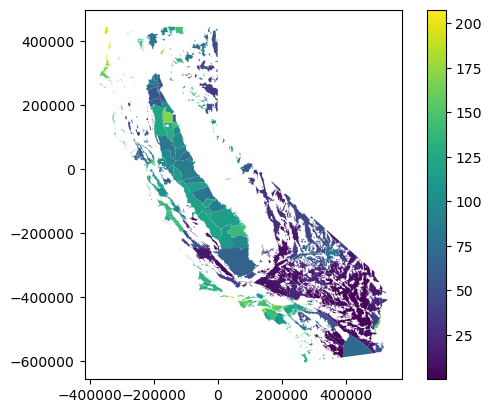

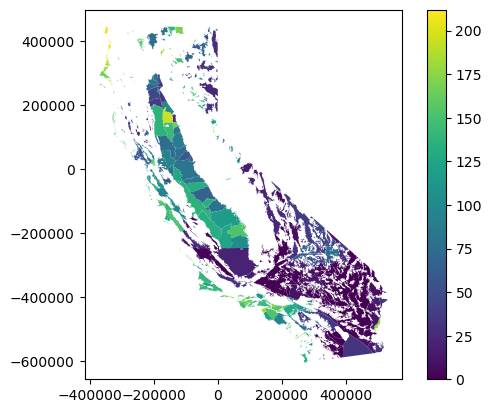

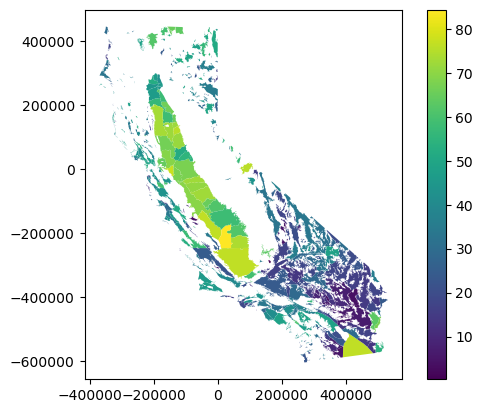

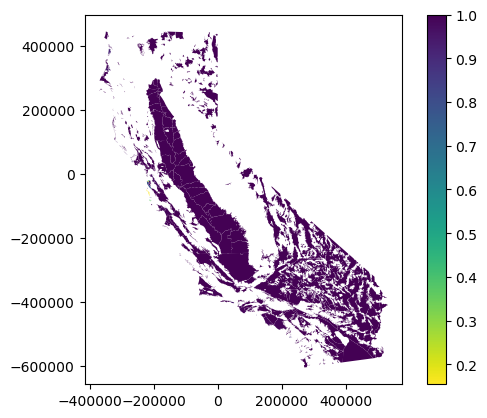

In [96]:
test_avg_gdf.plot(column=f'{modname}avg0407',cmap='viridis',legend=True)
test_median_gdf.plot(column=f'{modname}med0407',cmap='viridis',legend=True)
test_std_gdf.plot(column=f'{modname}std0407',cmap='viridis',legend=True)
test_cov_gdf.plot(column=f'{modname}cov0407',cmap='viridis_r',legend=True)